In [1]:
import numpy as np
import torch
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [52]:
def knn_consistency(knn1, knn2, ks, leniency=0., eps=1e-8):
    N, k_max = knn1.shape
    assert int(ks[-1] * (1 + leniency)) <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        compare_k = int(k * (1 + leniency))
        shared = ranking[np.arange(N)[:, None], neighbours] < compare_k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        ev = k * compare_k / (N - 1)  # Hypergeometric distribution with m=k
        overlap = (num_shared - ev + eps) / (k - ev + eps)  # Chance adjust
        overlaps.append(overlap)

    return np.array(overlaps)

In [26]:
X1 = np.random.rand(100, 64)
X2 = np.random.rand(100, 64)

k = 99

nn1 = NearestNeighbors(n_neighbors=k).fit(X1)
knn1 = nn1.kneighbors(return_distance=False)
nn2 = NearestNeighbors(n_neighbors=k).fit(X2)
knn2 = nn2.kneighbors(return_distance=False)

knn_consistency(knn1, knn2, [98])

array([0.01000001])

In [28]:
import pickle
with open('all_features.pkl', 'rb') as f:
    all_features = pickle.load(f)

In [29]:
N = all_features[0]['base'].shape[0]

In [53]:
k_range = np.unique(np.geomspace(1, 500, num=20, dtype=int))
leniency_range = [0., 0.1, 0.2, 0.5, 1.]

consistencies_dict = {}

knns = []
for i in [0, 1, 2]:
    print(i)
    features = all_features[i]['base']
    max_compare_k = int(k_range[-1] * (1 + leniency_range[-1]))
    nn = NearestNeighbors(n_neighbors=max_compare_k).fit(features)
    knn = nn.kneighbors(return_distance=False)
    knns.append(knn)

for leniency in leniency_range:
    avg_curve = (
        knn_consistency(knns[0], knns[1], ks=k_range, leniency=leniency)
        + knn_consistency(knns[0], knns[2], ks=k_range, leniency=leniency)
        + knn_consistency(knns[1], knns[2], ks=k_range, leniency=leniency)
    ) / 3

    consistencies_dict[leniency] = avg_curve

0
1
2


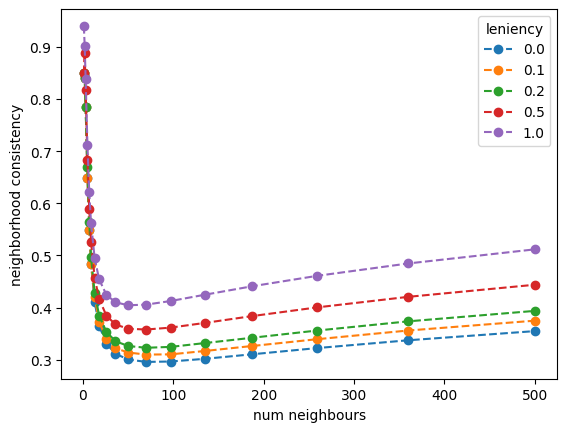

In [54]:
for leniency, curve in consistencies_dict.items():
    plt.plot(k_range, curve, ls='--', marker='o', label=leniency)

plt.xlabel('num neighbours')
plt.ylabel('neighborhood consistency')

plt.legend(title='leniency')
plt.show()

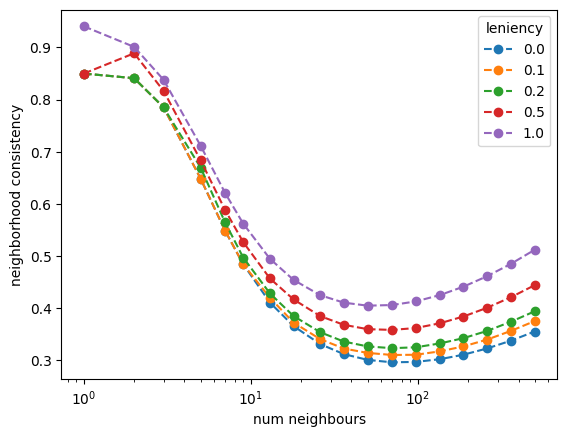

In [55]:
for leniency, curve in consistencies_dict.items():
    plt.plot(k_range, curve, ls='--', marker='o', label=leniency)

plt.xlabel('num neighbours')
plt.ylabel('neighborhood consistency')
plt.xscale('log')
plt.legend(title='leniency')
plt.show()